In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

**1. Carga de Datos**

In [5]:
df = pd.read_csv('weatherAUS_2026C1.csv')
df.head(5)

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


**1. ANÁLISIS DESCRIPTIVO INICIAL**

In [6]:
print("--- Estructura del Dataset ---")
print(df.info())
print("\n--- Estadísticas Descriptivas ---")
print(df.describe().T)

# ¿Qué es cada variable? (Resumen rápido)
# Numéricas: Temperaturas, Humedad, Presión, Velocidad viento (continuas).
# Categóricas: Location, WindDir, RainToday (factores).

--- Estructura del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        145412 non-null  int64  
 1   Date              145412 non-null  object 
 2   Location          145412 non-null  object 
 3   MinTemp           143928 non-null  float64
 4   MaxTemp           144159 non-null  float64
 5   Rainfall          142152 non-null  float64
 6   Evaporation       82658 non-null   float64
 7   Sunshine          75616 non-null   float64
 8   WindGustDir       135096 non-null  object 
 9   WindGustSpeed     135159 non-null  float64
 10  WindDir9am        134850 non-null  object 
 11  WindDir3pm        141186 non-null  object 
 12  WindSpeed9am      143645 non-null  float64
 13  WindSpeed3pm      142351 non-null  float64
 14  Humidity9am       142759 non-null  float64
 15  Humidity3pm       140907 non-null  fl

**2. ANÁLISIS DE DATOS FALTANTES**

In [7]:
print("\n--- Porcentaje de datos faltantes por columna ---")
missing_props = df.isnull().mean() * 100
print(missing_props[missing_props > 0].sort_values(ascending=False))

# Decisión: Eliminamos filas donde el target (RainTomorrow) es nulo
df = df.dropna(subset=['RainTomorrow'])


--- Porcentaje de datos faltantes por columna ---
Sunshine            47.998790
Evaporation         43.155998
Cloud3pm            40.805436
Cloud9am            38.421863
Pressure9am         10.357467
Pressure3pm         10.332022
WindDir9am           7.263500
WindGustDir          7.094325
WindGustSpeed        7.051000
Humidity3pm          3.098094
WindDir3pm           2.906225
Temp3pm              2.480538
Rainfall             2.241906
RainToday            2.241906
RainfallTomorrow     2.241218
RainTomorrow         2.241218
WindSpeed3pm         2.105053
Humidity9am          1.824471
WindSpeed9am         1.215168
Temp9am              1.214480
MinTemp              1.020549
MaxTemp              0.861690
dtype: float64


**3. VISUALIZACIÓN DE DATOS**

C:\Users\dananos\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


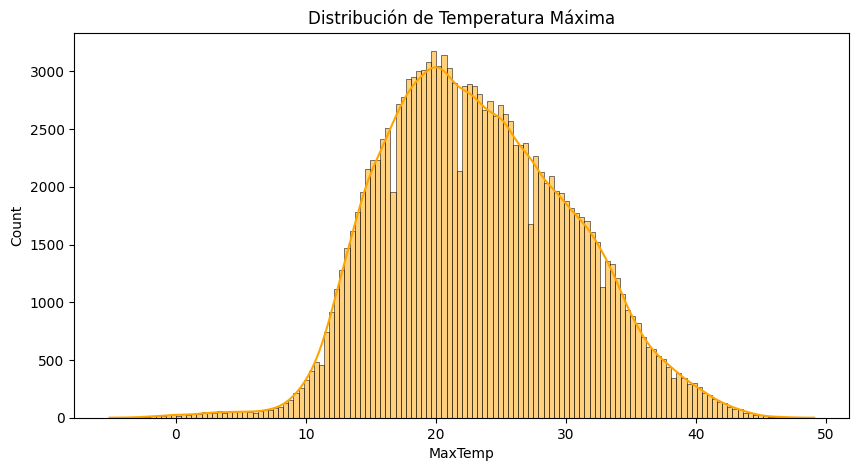

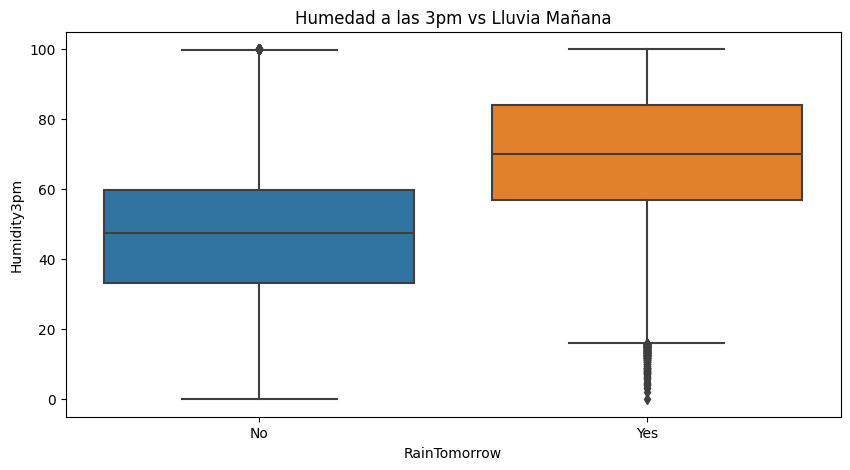

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df['MaxTemp'], kde=True, color='orange')
plt.title('Distribución de Temperatura Máxima')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x='RainTomorrow', y='Humidity3pm', data=df)
plt.title('Humedad a las 3pm vs Lluvia Mañana')
plt.show()

**4. BALANCE DEL DATASET**

In [ ]:
print("\n--- Balance del Target (RainTomorrow) ---")
balance = df['RainTomorrow'].value_counts(normalize=True) * 100
print(balance)

# ¿Por qué preguntamos esto? 
# Respuesta: Si hay un desbalance fuerte (por ejemplo: No = 80%: y Yes = 20%), el modelo podría 
# aprender a predecir siempre "No" y tener alta precisión pero ser inútil.


--- Balance del Target (RainTomorrow) ---
RainTomorrow
No     77.579087
Yes    22.420913
Name: proportion, dtype: float64


**5. CODIFICACIÓN DE VARIABLES CATEGÓRICAS (Pre-Split)**

In [10]:
# Codificamos binarias manualmente
df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1})
df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

# Para el resto (Location, WindDir), usaremos One-Hot encoding después o LabelEncoding ahora
# Aquí simplificamos con LabelEncoding para las direcciones y locación para facilitar la matriz
le = LabelEncoder()
cat_cols = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

**6. VALIDACIÓN CRUZADA (DIVISIÓN TRAIN - TEST)**

In [11]:
# Se hace aquí para evitar que el escalado "vea" información del set de prueba.
X = df.drop(['RainTomorrow', 'Date', 'Unnamed: 0', 'RainfallTomorrow'], axis=1, errors='ignore')
y = df['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nSet Entrenamiento: {X_train.shape}")
print(f"Set Prueba: {X_test.shape}")


Set Entrenamiento: (113722, 21)
Set Prueba: (28431, 21)


**7. MATRIZ DE CORRELACIÓN**

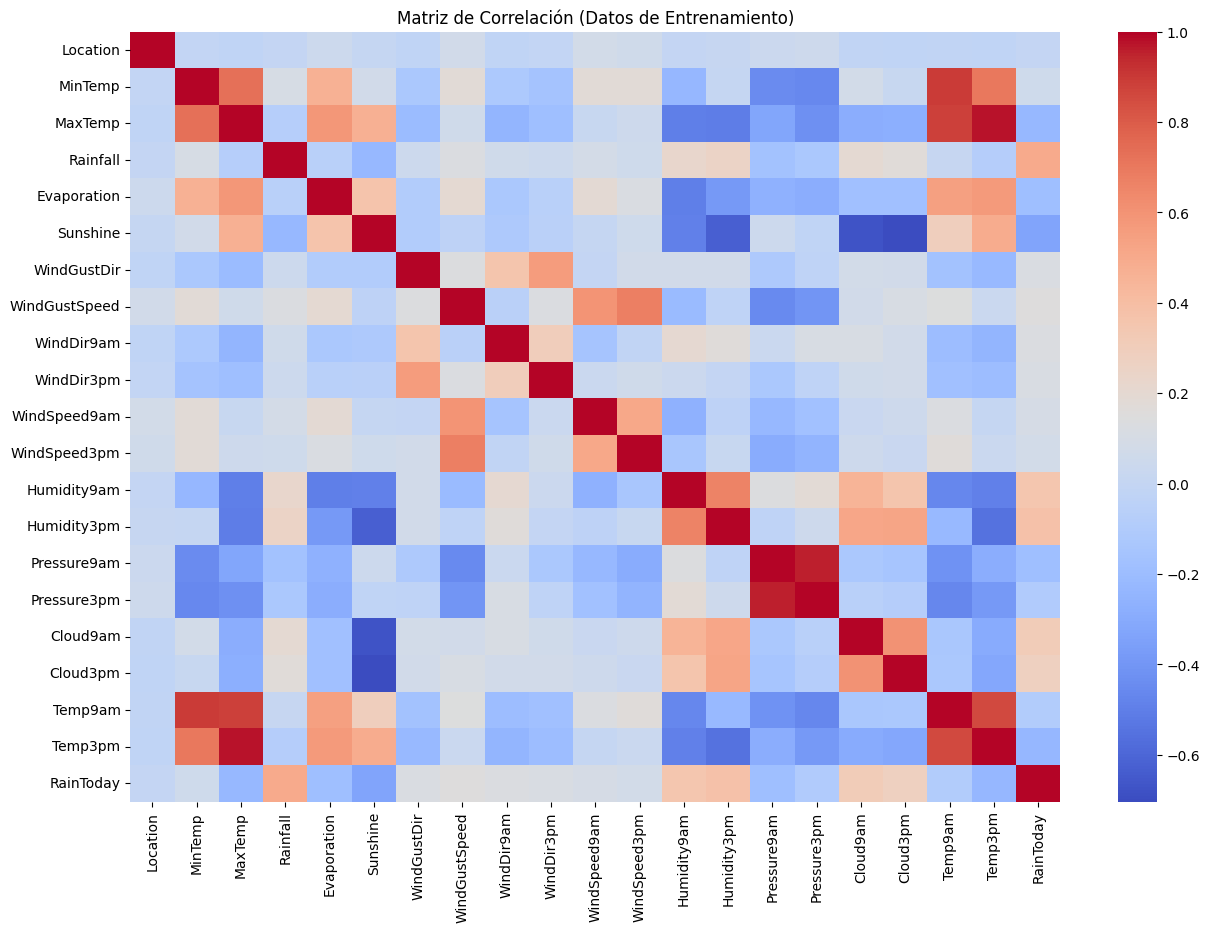

In [12]:
plt.figure(figsize=(15, 10))
sns.heatmap(X_train.corr(), annot=False, cmap='coolwarm')
plt.title('Matriz de Correlación (Datos de Entrenamiento)')
plt.show()

**8. ESTANDARIZACIÓN / ESCALADO**

In [13]:
# Imputamos nulos con la mediana antes de escalar (usando solo info de train)
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median()) # Ojo: usamos la mediana de TRAIN en TEST

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n--- Procesamiento Completado ---")
print("Datos listos para entrenamiento de modelos.")


--- Procesamiento Completado ---
Datos listos para entrenamiento de modelos.
